<a href="https://colab.research.google.com/github/ChristianAgyapong/Medgemma/blob/main/FINAL_TASK.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

print("TensorFlow version:", tf.__version__)

2026-03-23 13:16:41.368331: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774271801.548671      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774271801.599866      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774271802.005815      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774271802.005844      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774271802.005846      55 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0


In [ ]:
# Load MNIST (60,000 train + 10,000 test images of 28×28 pixels)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print("Training images shape:", x_train.shape)   # (60000, 28, 28)
print("Test images shape    :", x_test.shape)    # (10000, 28, 28)
print("Labels range:", y_train.min(), "to", y_train.max())  # 0 to 9

# Normalize pixel values to [0,1] range (very important for neural nets)
x_train = x_train.astype("float32") / 255.0
x_test  = x_test.astype("float32")  / 255.0

# Flatten 28×28 images into 784-dimensional vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test  = x_test.reshape(-1, 28 * 28)

print("\nAfter flattening → input shape:", x_train.shape[1])

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training images shape: (60000, 28, 28)
Test images shape    : (10000, 28, 28)
Labels range: 0 to 9

After flattening → input shape: 784


In [ ]:
model = keras.Sequential([
    # Input layer (implicit, but we specify input shape)
    layers.Input(shape=(784,)),

    # Hidden layer 1: 128 neurons, ReLU activation
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),           # helps stabilize training

    # Hidden layer 2: 64 neurons
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),                    # prevents overfitting

    # Output layer: 10 neurons (one per digit), softmax
    layers.Dense(10, activation='softmax')
])

# Summary of the model architecture
model.summary()

I0000 00:00:1774271862.950026      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1774271862.955986      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,898 (429.29 KB)

 Trainable params: 109,642 (428.29 KB)

 Non-trainable params: 256 (1.00 KB)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',   # best for integer labels 0–9
    metrics=['accuracy']
)

print("Model compiled successfully.")

Model compiled successfully.


In [ ]:
history = model.fit(
    x_train, y_train,
    epochs=15,                    # usually enough for MNIST
    batch_size=128,
    validation_split=0.2,         # 20% of training data used for validation
    verbose=1
)

Epoch 1/15


I0000 00:00:1774271911.030213    2835 service.cc:152] XLA service 0x7cbeb800cb10 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774271911.030240    2835 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1774271911.030244    2835 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1774271911.334408    2835 cuda_dnn.cc:529] Loaded cuDNN version 91002


 67/375 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5405 - loss: 1.4378

I0000 00:00:1774271912.857389    2835 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7923 - loss: 0.6745 - val_accuracy: 0.9564 - val_loss: 0.1582
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9526 - loss: 0.1598 - val_accuracy: 0.9651 - val_loss: 0.1201
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9682 - loss: 0.1077 - val_accuracy: 0.9672 - val_loss: 0.1059
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9759 - loss: 0.0783 - val_accuracy: 0.9688 - val_loss: 0.1021
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9814 - loss: 0.0615 - val_accuracy: 0.9685 - val_loss: 0.1033
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9836 - loss: 0.0536 - val_accuracy: 0.9703 - val_loss: 0.1035
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9867 - loss: 0.0447 - val_accuracy: 0.9719 - val_loss: 0.0969
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9885 - loss: 0.0361 - val_accuracy: 0.9711 - val_

In [ ]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=0)

print(f"\nTest accuracy: {test_acc:.4f}")
print(f"Test loss:     {test_loss:.4f}")


Test accuracy: 0.9775
Test loss:     0.0867


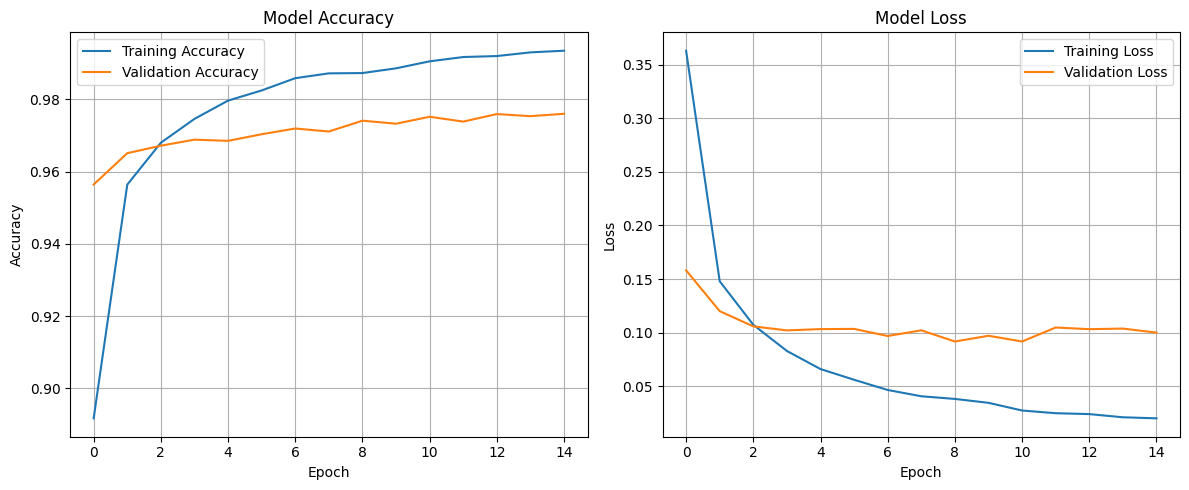

In [ ]:
plt.figure(figsize=(12, 5))

# Plot accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


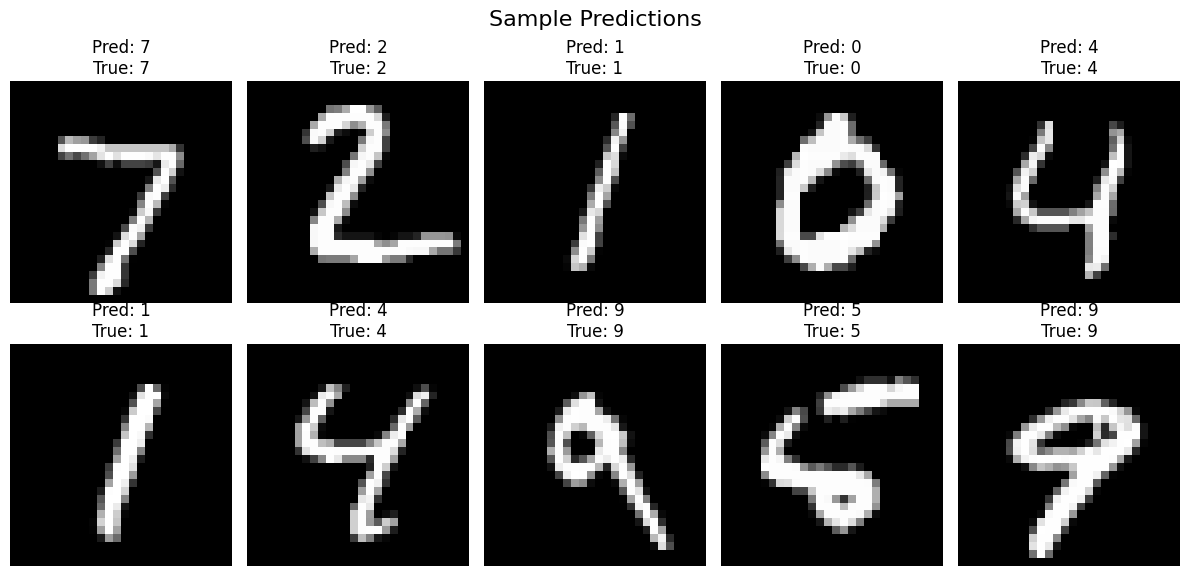

In [ ]:
# Predict on first 10 test images
predictions = model.predict(x_test[:10])
predicted_labels = np.argmax(predictions, axis=1)

# Show images + predictions
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i+1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {y_test[i]}")
    plt.axis('off')
plt.suptitle("Sample Predictions", fontsize=16)
plt.tight_layout()
plt.show()

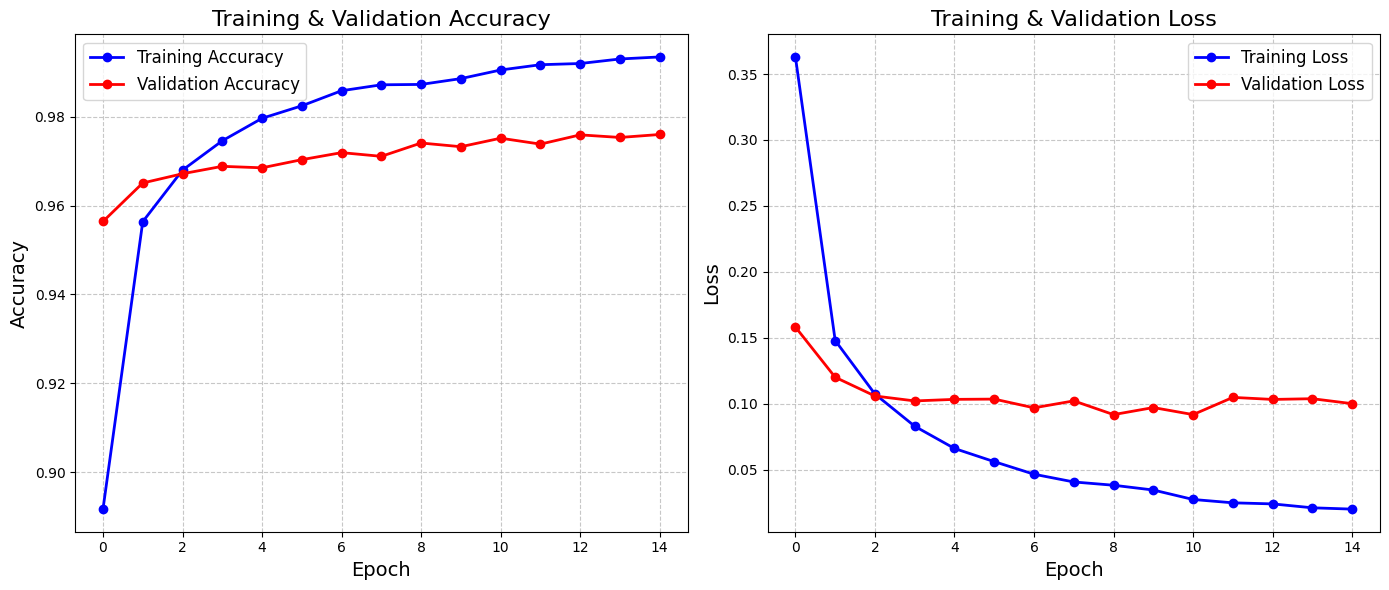

In [ ]:
plt.figure(figsize=(14, 6))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], 'b-o', label='Training Accuracy', linewidth=2)
plt.plot(history.history['val_accuracy'], 'r-o', label='Validation Accuracy', linewidth=2)
plt.title('Training & Validation Accuracy', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], 'b-o', label='Training Loss', linewidth=2)
plt.plot(history.history['val_loss'], 'r-o', label='Validation Loss', linewidth=2)
plt.title('Training & Validation Loss', fontsize=16)
plt.xlabel('Epoch', fontsize=14)
plt.ylabel('Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

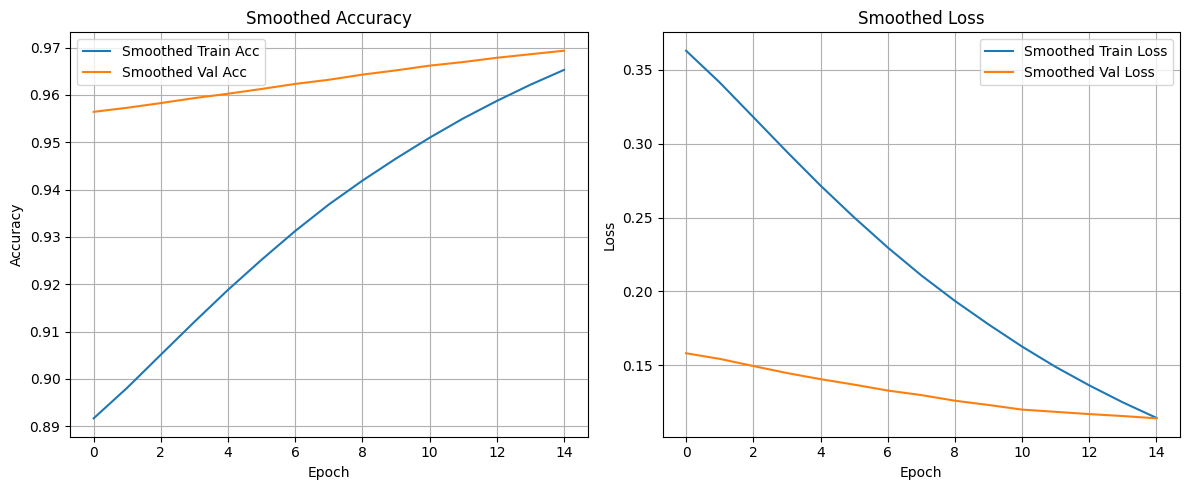

In [ ]:
def smooth_curve(points, factor=0.9):
    smoothed = []
    for point in points:
        if smoothed:
            previous = smoothed[-1]
            smoothed.append(previous * factor + point * (1 - factor))
        else:
            smoothed.append(point)
    return smoothed

plt.figure(figsize=(12, 5))

# Smoothed accuracy
plt.subplot(1, 2, 1)
plt.plot(smooth_curve(history.history['accuracy']), label='Smoothed Train Acc')
plt.plot(smooth_curve(history.history['val_accuracy']), label='Smoothed Val Acc')
plt.title('Smoothed Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Smoothed loss
plt.subplot(1, 2, 2)
plt.plot(smooth_curve(history.history['loss']), label='Smoothed Train Loss')
plt.plot(smooth_curve(history.history['val_loss']), label='Smoothed Val Loss')
plt.title('Smoothed Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

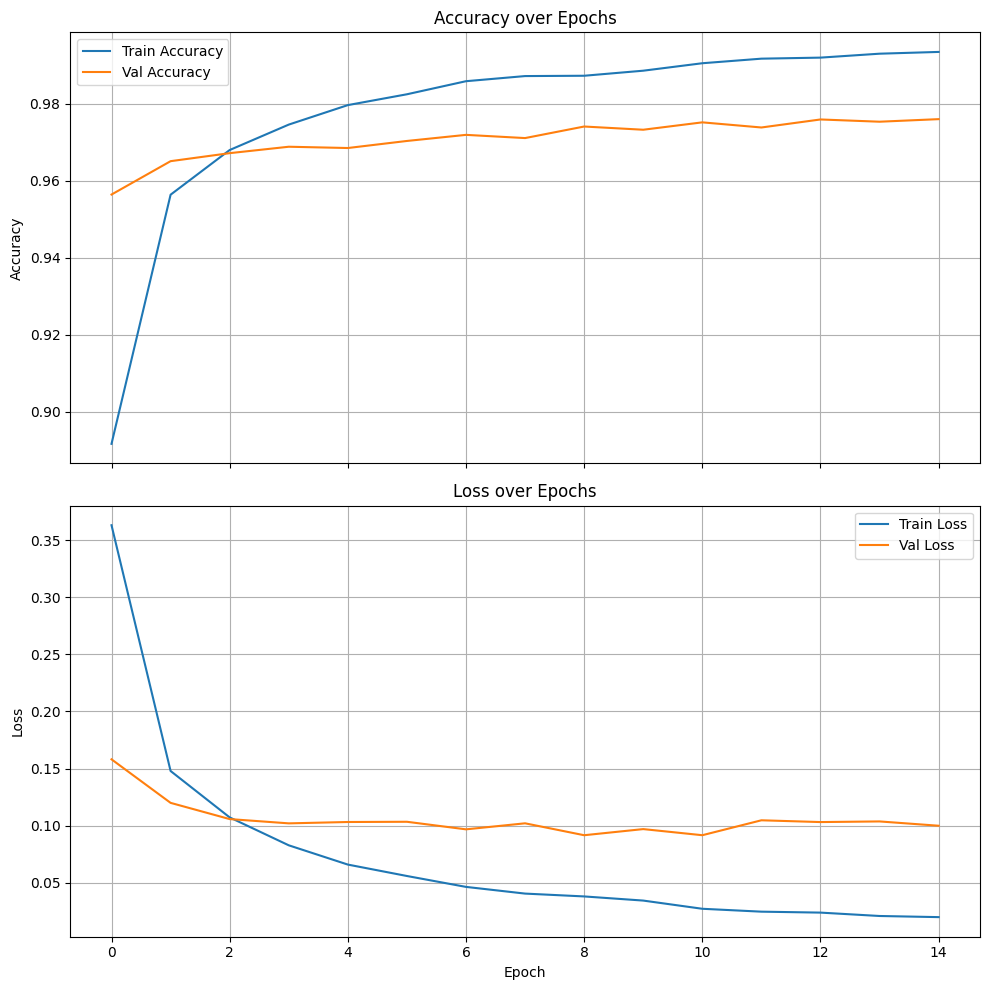

In [ ]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)

# Accuracy (top)
ax1.plot(history.history['accuracy'], label='Train Accuracy')
ax1.plot(history.history['val_accuracy'], label='Val Accuracy')
ax1.set_ylabel('Accuracy')
ax1.set_title('Accuracy over Epochs')
ax1.legend()
ax1.grid(True)

# Loss (bottom)
ax2.plot(history.history['loss'], label='Train Loss')
ax2.plot(history.history['val_loss'], label='Val Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.set_title('Loss over Epochs')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()